# Imports

In [33]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from sklearn.metrics import confusion_matrix

In [51]:
# Preprocessing Function
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    green = image[:, :, 1]  # Green channel
    return green

# Load Ground Truth
def load_mask(mask_path, fov_path):

    gt = cv2.imread(mask_path, 0)
    gt = gt > 0

    fov = cv2.imread(fov_path, 0)
    fov = fov > 0

    return gt, fov


## Why Use Green Channel? (Important)

In fundus images:

✔ Green channel shows vessels with the highest contrast  
✔ Red channel is too bright  
✔ Blue channel is too noisy  

In [15]:
image_path = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/21_training.tif"
mask_path  = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual/21_manual1.gif"

# Load image
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Load ground truth
gt = cv2.imread(mask_path, 0)
gt = gt > 0   # Convert to binary

In [23]:
def apply_niblack(image, window_size=25, k=-0.2):
    thresh = threshold_niblack(image,
                               window_size=window_size,
                               k=k)
    binary = image > thresh
    return binary

In [24]:
def apply_sauvola(image, window_size=25, k=0.3):
    thresh = threshold_sauvola(image,
                               window_size=window_size,
                               k=k)
    binary = image > thresh
    return binary

In [25]:
image_path = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/21_training.tif"
mask_path  = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual/21_manual1.gif"

image_green = preprocess_image(image_path)
gt = load_mask(mask_path)


In [26]:
binary_niblack = apply_niblack(image_green)
binary_sauvola = apply_sauvola(image_green)

In [27]:
def compute_sensitivity(pred, gt):
    TP = np.sum((pred == 1) & (gt == 1))
    FN = np.sum((pred == 0) & (gt == 1))
    return TP / (TP + FN)

sens_niblack = compute_sensitivity(binary_niblack, gt)
sens_sauvola = compute_sensitivity(binary_sauvola, gt)

print("Niblack Sensitivity:", sens_niblack)
print("Sauvola Sensitivity:", sens_sauvola)


Niblack Sensitivity: 0.08419174304485359
Sauvola Sensitivity: 0.9674345040149241


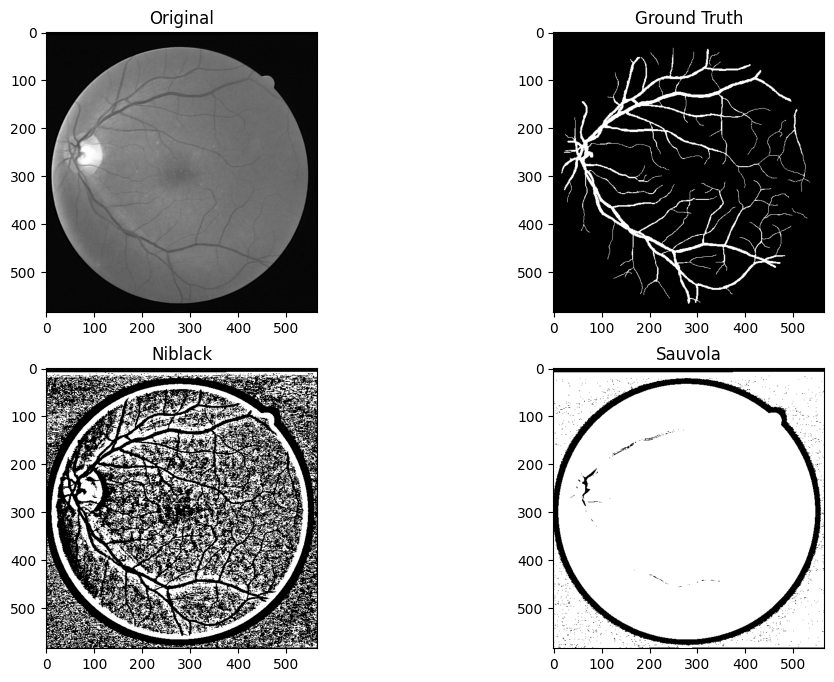

In [28]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(image_gray, cmap='gray')

plt.subplot(2,2,2)
plt.title("Ground Truth")
plt.imshow(gt, cmap='gray')

plt.subplot(2,2,3)
plt.title("Niblack")
plt.imshow(binary_niblack, cmap='gray')

plt.subplot(2,2,4)
plt.title("Sauvola")
plt.imshow(binary_sauvola, cmap='gray')

plt.show()

In [48]:
def batch_evaluate(image_dir, mask_dir, threshold_function,
                   window_size=25, k=0.2):

    sensitivities = []

    image_files = sorted(os.listdir(image_dir))

    for file in image_files:

        image_path = os.path.join(image_dir, file)
        
        mask_name = file.replace("_training.tif", "_manual1.gif")
        fov_name = file.replace("_training.tif", "_training_mask.gif")
        
        fov_path = os.path.join(fov_dir, fov_name)
        mask_path = os.path.join(mask_dir, mask_name)

        image = preprocess_image(image_path)
        gt, fov = load_mask(mask_path, fov_path)

        pred = threshold_function(image,
                                  window_size=window_size,
                                  k=k)

        # Apply FOV mask
        pred = pred & fov
        gt = gt & fov
        
        sens = compute_sensitivity(pred, gt)

        sensitivities.append(sens)

    return np.mean(sensitivities)


In [49]:
image_dir = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images"
mask_dir  = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual"
fov_dir = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/mask"

In [52]:
avg_sens_nib = batch_evaluate(
    image_dir,
    mask_dir,
    apply_niblack,
    window_size=25,
    k=-0.2
)
print("Niblack Average Sensitivity:", avg_sens_nib)

Niblack Average Sensitivity: 0.09995389039758226


In [53]:
avg_sens_sau = batch_evaluate(
    image_dir,
    mask_dir,
    apply_sauvola,
    window_size=25,
    k=0.3
)
print("Sauvola Average Sensitivity:", avg_sens_sau)

Sauvola Average Sensitivity: 0.9460511757097769
